In [1]:
#setup
from google.colab import drive
drive.mount('/content/drive')

import sys
from pathlib import Path

PROJECT_DIR = Path('/content/drive/MyDrive/Proyek_CRM_KELOMPOK')
sys.path.append(str(PROJECT_DIR))

from project_config import CLEAN_DATA_PATH, OUTPUT_DIR, REPORT_DIR

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

Mounted at /content/drive


In [2]:
# load data cleaning
df = pd.read_csv(CLEAN_DATA_PATH)

print(df.shape)
df.head()

(286, 56)


,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,latitude,longitude,Pin code,...,High Quality of package,Number of calls,Politeness,Freshness,Temperature,Good Taste,Good Quantity,Output,Reviews,churn_risk
0,20,Female,Single,Student,No Income,Post Graduate,4,12.9766,77.5993,560001,...,Moderately Important,Moderately Important,Moderately Important,Moderately Important,Moderately Important,Moderately Important,Moderately Important,Yes,Nil,0
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,12.9770,77.5773,560009,...,Very Important,Very Important,Very Important,Very Important,Very Important,Very Important,Very Important,Yes,Nil,0
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,12.9551,77.6593,560017,...,Very Important,Moderately Important,Very Important,Very Important,Important,Very Important,Moderately Important,Yes,"Many a times payment gateways are an issue, so...",0
3,22,Female,Single,Student,No Income,Graduate,6,12.9473,77.5616,560019,...,Important,Moderately Important,Very Important,Very Important,Very Important,Very Important,Important,Yes,nil,0
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,12.9850,77.5533,560010,...,Important,Moderately Important,Important,Important,Important,Very Important,Very Important,Yes,NIL,0


In [3]:
# Fungsi churn rate
def churn_rate_table(data, column):
    result = (
        data.groupby(column)
        .agg(
            total_customer=('churn_risk', 'count'),
            churn_customer=('churn_risk', 'sum'),
            churn_rate=('churn_risk', 'mean')
        )
        .reset_index()
        .sort_values('churn_rate', ascending=False)
    )

    result['churn_rate'] = result['churn_rate'] * 100
    return result

In [4]:
# Target summary
target_summary = (
    df.groupby('Output')
    .agg(total_customer=('Output', 'count'))
    .reset_index()
)

target_summary['percent'] = target_summary['total_customer'] / target_summary['total_customer'].sum() * 100

target_summary

,Output,total_customer,percent
0,No,65,22.727273
1,Yes,221,77.272727


In [5]:
# simpan target summary

target_summary_path = OUTPUT_DIR / 'eda_target_summary.csv'
target_summary.to_csv(target_summary_path, index=False)

print('Output disimpan:', target_summary_path)

Output disimpan: /content/drive/MyDrive/Proyek_CRM_KELOMPOK/outputs/eda_target_summary.csv


In [8]:
# buat age group
df['age_group'] = pd.cut(
    df['Age'],
    bins=[17, 20, 23, 26, 100],
    labels=['<=20', '21-23', '24-26', '27+']
)

In [9]:
# EDA demografi
demographic_columns = [
    'age_group',
    'Gender',
    'Marital Status',
    'Occupation',
    'Monthly Income',
    'Educational Qualifications',
    'Family size'
]

demographic_columns = [col for col in demographic_columns if col in df.columns]

demo_summary_list = []

for col in demographic_columns:
    temp = churn_rate_table(df, col)
    temp['analysis_column'] = col
    demo_summary_list.append(temp)

demo_summary = pd.concat(demo_summary_list, ignore_index=True)
demo_summary.head(20)

/tmp/ipykernel_5415/2038700116.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(column)


,age_group,total_customer,churn_customer,churn_rate,analysis_column,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size
0,27+,61,25,40.983607,age_group,NaN,NaN,NaN,NaN,NaN,NaN
1,24-26,107,27,25.233645,age_group,NaN,NaN,NaN,NaN,NaN,NaN
2,<=20,12,2,16.666667,age_group,NaN,NaN,NaN,NaN,NaN,NaN
3,21-23,106,11,10.377358,age_group,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,122,30,24.590164,Gender,Female,NaN,NaN,NaN,NaN,NaN
5,NaN,164,35,21.341463,Gender,Male,NaN,NaN,NaN,NaN,NaN
6,NaN,9,5,55.555556,Marital Status,NaN,Prefer not to say,NaN,NaN,NaN,NaN
7,NaN,85,32,37.647059,Marital Status,NaN,Married,NaN,NaN,NaN,NaN
8,NaN,192,28,14.583333,Marital Status,NaN,Single,NaN,NaN,NaN,NaN
9,NaN,93,33,35.483871,Occupation,NaN,NaN,Employee,NaN,NaN,NaN


In [10]:
#simpan EDA demografi
demo_summary_path = OUTPUT_DIR / 'eda_demographic_churn_summary.csv'
demo_summary.to_csv(demo_summary_path, index=False)

print('Output disimpan:', demo_summary_path)

Output disimpan: /content/drive/MyDrive/Proyek_CRM_KELOMPOK/outputs/eda_demographic_churn_summary.csv


/tmp/ipykernel_5415/2038700116.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(column)


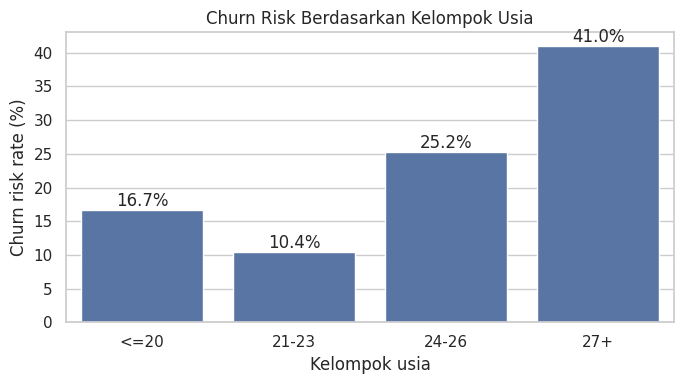

In [11]:
# Grafik churn by age
age_churn = churn_rate_table(df, 'age_group')

plt.figure(figsize=(7, 4))
ax = sns.barplot(data=age_churn, x='age_group', y='churn_rate')

plt.title('Churn Risk Berdasarkan Kelompok Usia')
plt.xlabel('Kelompok usia')
plt.ylabel('Churn risk rate (%)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.tight_layout()

chart_path = OUTPUT_DIR / '02_churn_by_age_group.png'
plt.savefig(chart_path, dpi=300, bbox_inches='tight')
plt.show()

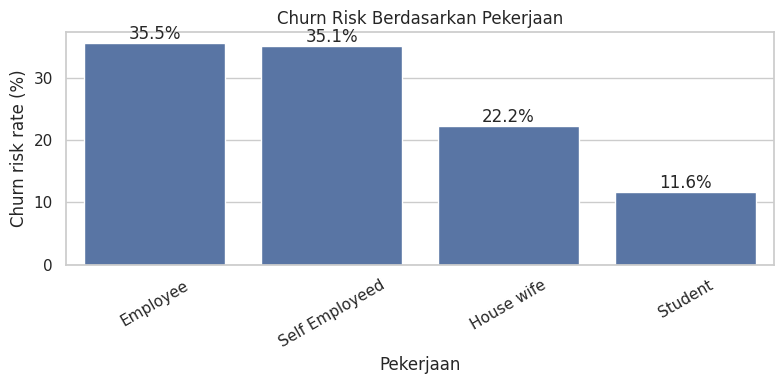

In [12]:
# Grafik churn by occupation
occupation_churn = churn_rate_table(df, 'Occupation')

plt.figure(figsize=(8, 4))
ax = sns.barplot(data=occupation_churn, x='Occupation', y='churn_rate')

plt.title('Churn Risk Berdasarkan Pekerjaan')
plt.xlabel('Pekerjaan')
plt.ylabel('Churn risk rate (%)')
plt.xticks(rotation=30)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.tight_layout()

chart_path = OUTPUT_DIR / '03_churn_by_occupation.png'
plt.savefig(chart_path, dpi=300, bbox_inches='tight')
plt.show()

In [13]:
# EDA faktor service
service_columns = [
    'Ease and convenient',
    'Time saving',
    'Maximum wait time',
    'More restaurant choices',
    'More Offers and Discount',
    'Late Delivery',
    'Good Food quality',
    'Easy Payment option',
    'Google Maps Accuracy'
]

service_columns = [col for col in service_columns if col in df.columns]

service_summary_list = []

for col in service_columns:
    temp = churn_rate_table(df, col)
    temp['analysis_column'] = col
    service_summary_list.append(temp)

service_summary = pd.concat(service_summary_list, ignore_index=True)
service_summary.head(20)

,Ease and convenient,total_customer,churn_customer,churn_rate,analysis_column,Time saving,Maximum wait time,More restaurant choices,More Offers and Discount,Late Delivery,Good Food quality,Easy Payment option,Google Maps Accuracy
0,Disagree,43,37,86.046512,Ease and convenient,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Strongly disagree,6,3,50.000000,Ease and convenient,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Neutral,16,4,25.000000,Ease and convenient,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Agree,176,20,11.363636,Ease and convenient,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Strongly agree,45,1,2.222222,Ease and convenient,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,50,38,76.000000,Time saving,Disagree,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,9,5,55.555556,Time saving,Strongly disagree,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,40,8,20.000000,Time saving,Neutral,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,103,9,8.737864,Time saving,Agree,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,84,5,5.952381,Time saving,Strongly agree,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# simpan EDA faktor service
service_summary_path = OUTPUT_DIR / 'eda_service_churn_summary.csv'
service_summary.to_csv(service_summary_path, index=False)

print('Output disimpan:', service_summary_path)

Output disimpan: /content/drive/MyDrive/Proyek_CRM_KELOMPOK/outputs/eda_service_churn_summary.csv


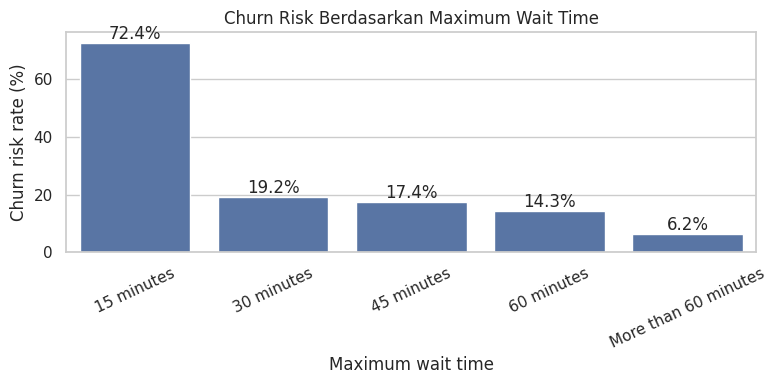

In [15]:
# Grafik maksimum wait time
if 'Maximum wait time' in df.columns:
    wait_churn = churn_rate_table(df, 'Maximum wait time')

    plt.figure(figsize=(8, 4))
    ax = sns.barplot(data=wait_churn, x='Maximum wait time', y='churn_rate')

    plt.title('Churn Risk Berdasarkan Maximum Wait Time')
    plt.xlabel('Maximum wait time')
    plt.ylabel('Churn risk rate (%)')
    plt.xticks(rotation=25)

    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%')

    plt.tight_layout()

    chart_path = OUTPUT_DIR / '05_churn_by_wait_time.png'
    plt.savefig(chart_path, dpi=300, bbox_inches='tight')
    plt.show()

In [16]:
# buat catatan insight
risk_rate = df['churn_risk'].mean() * 100

top_age = churn_rate_table(df, 'age_group').iloc[0]
top_occupation = churn_rate_table(df, 'Occupation').iloc[0]

insight_notes = f"""
Insight EDA Awal

1. Total pelanggan: {len(df)}
2. Churn risk rate aktual: {risk_rate:.2f}%
3. Kelompok usia dengan risiko tertinggi: {top_age['age_group']} dengan churn rate {top_age['churn_rate']:.2f}%
4. Pekerjaan dengan risiko tertinggi: {top_occupation['Occupation']} dengan churn rate {top_occupation['churn_rate']:.2f}%

Interpretasi CRM:
Pelanggan berisiko perlu dianalisis berdasarkan profil demografi dan faktor layanan. Strategi CRM sebaiknya diarahkan ke segmen dengan risiko tinggi, bukan dibagikan sama rata ke semua pelanggan.
"""

notes_path = REPORT_DIR / 'eda_insight_notes.txt'

with open(notes_path, 'w') as f:
    f.write(insight_notes)

print(insight_notes)
print('Insight notes disimpan:', notes_path)


Insight EDA Awal

1. Total pelanggan: 286
2. Churn risk rate aktual: 22.73%
3. Kelompok usia dengan risiko tertinggi: 27+ dengan churn rate 40.98%
4. Pekerjaan dengan risiko tertinggi: Employee dengan churn rate 35.48%

Interpretasi CRM:
Pelanggan berisiko perlu dianalisis berdasarkan profil demografi dan faktor layanan. Strategi CRM sebaiknya diarahkan ke segmen dengan risiko tinggi, bukan dibagikan sama rata ke semua pelanggan.

Insight notes disimpan: /content/drive/MyDrive/Proyek_CRM_KELOMPOK/reports/eda_insight_notes.txt


/tmp/ipykernel_5415/2038700116.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(column)
